In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import requests
from io import StringIO

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

pinguins = pd.read_csv(StringIO(requests.get(url).text))

In [4]:
pinguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
pinguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [6]:
pinguins = pinguins.dropna()

In [7]:
pinguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 23.4 KB


In [8]:
pinguins["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [9]:
pinguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [10]:
num_data = pinguins[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

In [11]:
corr = num_data.corr()
corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


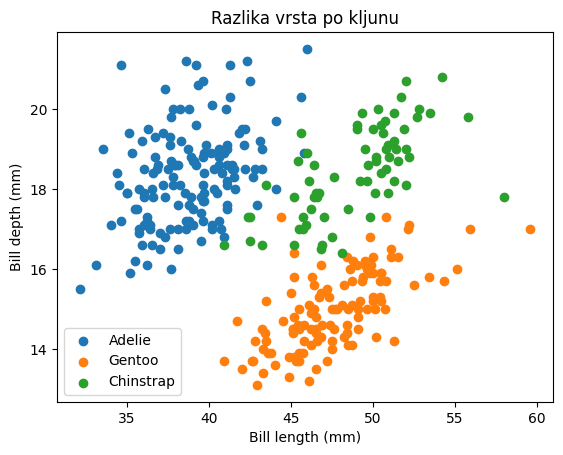

In [13]:
import matplotlib.pyplot as plt

for species in pinguins["species"].unique():
    data = pinguins[pinguins["species"] == species]
    plt.scatter(data["bill_length_mm"], data["bill_depth_mm"], label=species)

plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.legend()
plt.title("Razlika vrsta po kljunu")
plt.show()

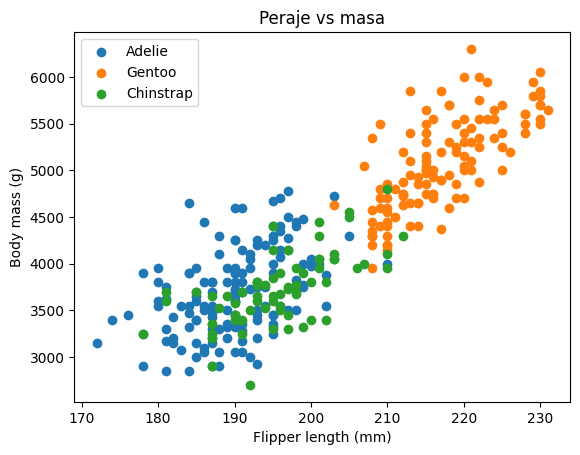

In [14]:
for species in pinguins["species"].unique():
    data = pinguins[pinguins["species"] == species]
    plt.scatter(data["flipper_length_mm"], data["body_mass_g"], label=species)

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.legend()
plt.title("Peraje vs masa")
plt.show()

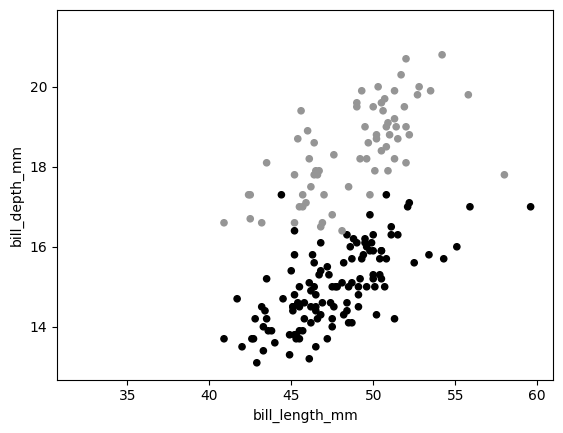

In [15]:
pinguins.plot.scatter(x="bill_length_mm", y="bill_depth_mm", c=pinguins["species"].astype("category").cat.codes)
plt.show()